<a href="https://colab.research.google.com/github/francji1/01ZLMA/blob/main/code/01ZLMA_ex08_LLM_solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01ZLMA - Exercise 08 - Solutions

Companion to the main notebook `01ZLMA_ex08_Binary_Data_Prediction.ipynb`.

**Part A** gives fully worked solutions to every T-task (theory) and A-task (applied) from the main notebook.

**Part B** presents Monte Carlo studies verifying each of the headline claims made in the main notebook.

## Contents

- [Part A - Theory solutions (T1-T7)](#part-a-theory)
- [Part A - Applied solutions (A1-A6, Heart)](#part-a-applied-heart)
- [Part A - Applied solution (A7, Breast Cancer)](#part-a-applied-bc)
- [Part B - Monte Carlo studies (MC1-MC6)](#part-b-mc)
- [Summary mapping](#summary-mapping)


## Setup

In [1]:
import numpy as np
import pandas as pd

import scipy
from scipy import stats
from scipy.stats import chi2, norm

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families.links import Logit, Probit, CLogLog

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, RocCurveDisplay,
    brier_score_loss, log_loss,
    precision_recall_fscore_support, matthews_corrcoef, cohen_kappa_score,
    f1_score, accuracy_score, balanced_accuracy_score,
)
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.datasets import load_breast_cancer

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import seaborn as sns
sns.set_theme(style="whitegrid")

import io
import os
import sys
import requests
import warnings
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

rng = np.random.default_rng(20260421)


In [2]:
# Load helpers.py - works in Colab and locally.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget venn-abers
    import wget
    wget.download(
        "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py",
        "helpers.py",
    )
else:
    helpers_dir = os.path.dirname(os.path.abspath("__file__"))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova, DiagnosticPlots
anova = Anova()


In [3]:
BASE_URL = "https://raw.githubusercontent.com/francji1/01ZLMA/main/data/"

def load_csv(name, sep=","):
    r = requests.get(BASE_URL + name, verify=False)
    r.raise_for_status()
    return pd.read_csv(io.StringIO(r.text), sep=sep)


def OR_ci(model, var_name, alpha=0.05):
    beta = model.params[var_name]
    se = model.bse[var_name]
    z = norm.ppf(1 - alpha / 2)
    return pd.DataFrame(
        {"OR": [np.exp(beta)], "LCL": [np.exp(beta - z * se)], "UCL": [np.exp(beta + z * se)]},
        index=[var_name],
    )


def invlogit(x):
    return 1 / (1 + np.exp(-x))


In [4]:
# Heart baseline: same setup as the main notebook §4.
heart_train = load_csv("heart_train.csv")
heart_test  = load_csv("heart_test.csv")

# Harmonize sex encoding (train: "male"/"female", test: 1/0).
sex_map = {1: "male", 0: "female"}
if heart_test["sex"].dtype.kind in "iu":
    heart_test["sex"] = heart_test["sex"].map(sex_map)
if heart_train["sex"].dtype.kind in "iu":
    heart_train["sex"] = heart_train["sex"].map(sex_map)

formula = ("disease ~ age + sex + chest_pain_type + blood_pressure + cholesterol "
           "+ blood_sugar + rest_ecg + heart_rate + ex_angina "
           "+ st_depression + st_slope + num_vessels + thal")
m_logit = smf.glm(formula, data=heart_train, family=sm.families.Binomial()).fit()

X_train = pd.get_dummies(heart_train.drop(columns="disease"), drop_first=True).astype(float)
X_test  = pd.get_dummies(heart_test.drop(columns="disease"),  drop_first=True).astype(float)
X_test  = X_test.reindex(columns=X_train.columns, fill_value=0)
y_train = heart_train["disease"].values
y_test  = heart_test["disease"].values
p_test  = m_logit.predict(heart_test).values

# Shared HL statistic helper used by several MC tasks.
def hl_stat(p, y, g=10):
    df = pd.DataFrame({"p": p, "y": y})
    df["bin"] = pd.qcut(df["p"], q=g, duplicates="drop")
    tbl = df.groupby("bin", observed=True).agg(o=("y", "sum"), e=("p", "sum"), n=("y", "size"))
    hl = ((tbl["o"] - tbl["e"])**2 / (tbl["e"] * (1 - tbl["e"] / tbl["n"]))).sum()
    return hl, 1 - chi2.cdf(hl, df=len(tbl) - 2)

print("Solutions setup ready:",
      f"train shape={heart_train.shape}, test shape={heart_test.shape},",
      f"test prevalence={y_test.mean():.2f}")


Solutions setup ready: train shape=(273, 14), test shape=(30, 14), test prevalence=0.53


---
# Part A - Theory solutions <a id="part-a-theory"></a>

## T1 - Murphy decomposition of the Brier score

Given predictions $\hat p_i$, labels $y_i \in \{0, 1\}$, a binning $\mathcal{B}_1, \dots, \mathcal{B}_K$ of the score range, and

* $n_k = |\mathcal{B}_k|$, $\bar p_k = n_k^{-1}\sum_{i \in \mathcal{B}_k} \hat p_i$, $\bar y_k = n_k^{-1}\sum_{i \in \mathcal{B}_k} y_i$,
* $\bar y = n^{-1}\sum_i y_i$,

define the **binned predictor** $\tilde\pi_i = \bar p_k$ for $i \in \mathcal{B}_k$. We prove Murphy's decomposition for $\tilde\pi$ (the exact identity) and then quantify the approximation error for the raw predictor $\hat\pi$.

### Step 1: exact identity for $\tilde\pi$

$$ \mathrm{BS}(\tilde\pi) = \frac{1}{n}\sum_k\sum_{i\in\mathcal{B}_k}(\bar p_k - y_i)^2. $$

Add and subtract $\bar y_k$:

$$ (\bar p_k - y_i)^2 = (\bar p_k - \bar y_k)^2 + 2(\bar p_k - \bar y_k)(\bar y_k - y_i) + (\bar y_k - y_i)^2. $$

Because $\bar p_k$ is *constant* on $\mathcal{B}_k$, the cross-term factors out of the inner sum:

$$ \sum_{i\in\mathcal{B}_k} 2(\bar p_k - \bar y_k)(\bar y_k - y_i) = 2(\bar p_k - \bar y_k)\sum_{i\in\mathcal{B}_k}(\bar y_k - y_i) = 0, $$

since $\sum_{i\in\mathcal{B}_k}(\bar y_k - y_i) = n_k\bar y_k - \sum_{i\in\mathcal{B}_k} y_i = 0$ by definition of $\bar y_k$. This is where the step fails for raw $\hat p_i$: the factor $(\hat p_i - \bar y_k)$ varies within the bin, so the sum is generally nonzero. The binned substitution $\hat p_i \mapsto \bar p_k$ is what makes the argument exact.

With the cross-term killed,

$$ \mathrm{BS}(\tilde\pi) = \underbrace{\sum_k \frac{n_k}{n}(\bar p_k - \bar y_k)^2}_{\text{reliability}} + \frac{1}{n}\sum_k\sum_{i\in\mathcal{B}_k}(\bar y_k - y_i)^2. $$

Expand the second term using $\bar y_k - y_i = (\bar y_k - \bar y) - (y_i - \bar y)$ and note that $y_i(1 - y_i) = 0$ for binary $y_i$, so $y_i^2 = y_i$ and hence $\frac{1}{n}\sum_i(y_i - \bar y)^2 = \bar y - \bar y^2 = \bar y(1-\bar y)$. After the algebra,

$$ \frac{1}{n}\sum_k\sum_{i\in\mathcal{B}_k}(\bar y_k - y_i)^2 = \bar y(1-\bar y) - \sum_k \frac{n_k}{n}(\bar y_k - \bar y)^2. $$

Combining:

$$ \boxed{\mathrm{BS}(\tilde\pi) = \underbrace{\sum_k \frac{n_k}{n}(\bar p_k - \bar y_k)^2}_{\text{reliability} \,\geq\, 0} \;-\; \underbrace{\sum_k \frac{n_k}{n}(\bar y_k - \bar y)^2}_{\text{resolution} \,\geq\, 0} \;+\; \underbrace{\bar y(1-\bar y)}_{\text{uncertainty}}.} $$

Both reliability and resolution are non-negative by construction; uncertainty is fixed by the data.

### Step 2: approximation gap for raw $\hat\pi$

Applying the decomposition formula $(\mathrm{rel} - \mathrm{res} + \mathrm{unc})$ to raw predictions $\hat\pi$ (using bin-means of $\hat\pi$ inside $\mathrm{rel}$) gives exactly $\mathrm{BS}(\tilde\pi)$, not $\mathrm{BS}(\hat\pi)$. Expanding $\mathrm{BS}(\hat\pi) - \mathrm{BS}(\tilde\pi)$ using $\hat\pi_i = (\hat\pi_i - \bar p_k) + \bar p_k$ and $\sum_{i\in\mathcal{B}_k}(\hat\pi_i - \bar p_k) = 0$:

$$ \mathrm{BS}(\hat\pi) - \mathrm{BS}(\tilde\pi) \;=\; \underbrace{\frac{1}{n}\sum_k\sum_{i\in\mathcal{B}_k}(\hat\pi_i - \bar p_k)^2}_{\text{within-bin variance of } \hat\pi \,\geq\, 0} \;-\; \underbrace{\frac{2}{n}\sum_k\sum_{i\in\mathcal{B}_k}(y_i - \bar y_k)(\hat\pi_i - \bar p_k)}_{\text{twice the within-bin covariance of } y \text{ and } \hat\pi}. $$

Both correction terms are of order within-bin variance (the covariance term is bounded in magnitude by $\sqrt{\mathrm{Var}(y)\,\mathrm{Var}(\hat\pi)}$ within each bin). The **sign** of the gap depends on which correction dominates:

- **Calibrated predictors** ($\hat\pi \approx E[y \mid x]$): within each bin, $\hat\pi$ and $y$ are positively correlated, so the covariance term is large and typically $\mathrm{BS}(\hat\pi) < \mathrm{BS}(\tilde\pi)$ - sharpening beats binning.
- **Severely miscalibrated predictors**: within-bin covariance is small; the within-bin variance dominates, giving $\mathrm{BS}(\hat\pi) > \mathrm{BS}(\tilde\pi)$.

In either regime the gap is ${\cal O}(\text{within-bin variance})$, so for fine binning $(\mathrm{rel} - \mathrm{res} + \mathrm{unc})$ remains a useful approximation to $\mathrm{BS}(\hat\pi)$. MC3 verifies all four quantities numerically.


In [5]:
# Numeric verification on heart_test predictions.
def brier_decomposition(p, y, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    df = pd.DataFrame({"p": p, "y": y, "b": idx})
    n = len(df); y_bar = df["y"].mean()
    rel = res = 0.0
    for _, g in df.groupby("b"):
        n_k = len(g)
        rel += n_k/n * (g["p"].mean() - g["y"].mean())**2
        res += n_k/n * (g["y"].mean() - y_bar)**2
    unc = y_bar * (1 - y_bar)
    return rel, res, unc

rel, res, unc = brier_decomposition(p_test, y_test)
print(f"BS direct: {brier_score_loss(y_test, p_test):.4f}  |  decomp: {rel - res + unc:.4f}")


BS direct: 0.1469  |  decomp: 0.1458


## T2 - Convergence of sklearn L2-LR to the MLE as $C \to \infty$

The sklearn objective is (ignoring the intercept for brevity)

$$ J_C(\beta) = -\ell(\beta) + \frac{1}{2C}\|\beta\|^2. $$

Its gradient is $\nabla J_C(\beta) = -\nabla\ell(\beta) + \beta/C$. The MLE $\hat\beta_{\text{MLE}}$ satisfies $\nabla\ell = 0$, so at $\beta = \hat\beta_{\text{MLE}}$ the sklearn gradient equals $\hat\beta_{\text{MLE}}/C$. By a first-order Taylor expansion around $\hat\beta_C = \arg\min J_C$,

$$ \hat\beta_C - \hat\beta_{\text{MLE}} \approx -\Big(\mathcal{I}(\hat\beta_{\text{MLE}}) + I/C\Big)^{-1}\,\hat\beta_{\text{MLE}}/C. $$

Multiplying through, $\|\hat\beta_C - \hat\beta_{\text{MLE}}\| \leq \|\hat\beta_{\text{MLE}}\| / (C \lambda_{\min}(\mathcal{I}))$ for large $C$, where $\lambda_{\min}$ is the smallest eigenvalue of the Fisher information. Thus the convergence is $O(1/C)$.


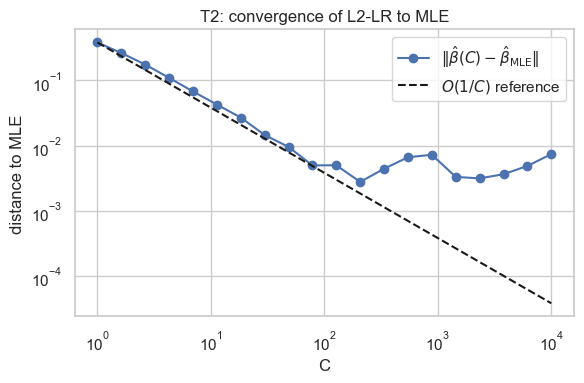

In [6]:
# Numerical verification of the O(1/C) rate on Heart.
lr_mle = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000).fit(X_train.values, y_train)
beta_mle = lr_mle.coef_.ravel()

Cs = np.logspace(0, 4, 20)
dists = []
for C in Cs:
    lr = LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=5000).fit(X_train.values, y_train)
    dists.append(np.linalg.norm(lr.coef_.ravel() - beta_mle))

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(Cs, dists, "o-", label=r"$\|\hat\beta(C) - \hat\beta_{\mathrm{MLE}}\|$")
ax.loglog(Cs, dists[0] * Cs[0] / Cs, "k--", label=r"$O(1/C)$ reference")
ax.set_xlabel("C"); ax.set_ylabel("distance to MLE"); ax.legend()
ax.set_title("T2: convergence of L2-LR to MLE")
plt.tight_layout(); plt.show()


## T3 - Delta-method standard error of $\hat\pi(x)$

With $\hat\pi(x) = \sigma(x^\top\hat\beta)$, by the delta method

$$ \widehat{\mathrm{Var}}(\hat\pi(x)) = \big(\sigma'(\hat\eta(x))\big)^2 \cdot x^\top\widehat{\mathrm{Cov}}(\hat\beta)\,x, $$

where $\sigma'(t) = \sigma(t)(1-\sigma(t)) = \hat\pi(1-\hat\pi)$. Hence

$$ \mathrm{se}_{\text{delta}}(\hat\pi(x)) = \hat\pi(1-\hat\pi)\,\sqrt{x^\top\widehat{\mathrm{Cov}}(\hat\beta)\,x}. $$

### Inequality against $\sqrt{\hat\pi(1-\hat\pi)}$

$$ \mathrm{se}_{\text{delta}}(\hat\pi(x)) \;<\; \sqrt{\hat\pi(1-\hat\pi)} \quad\Longleftrightarrow\quad \hat\pi(1-\hat\pi)\,\sqrt{x^\top\widehat{\mathrm{Cov}}(\hat\beta)\,x} \;<\; \sqrt{\hat\pi(1-\hat\pi)} \quad\Longleftrightarrow\quad x^\top\widehat{\mathrm{Cov}}(\hat\beta)\,x \;<\; \frac{1}{\hat\pi(1-\hat\pi)}. $$

Since $\hat\pi(1-\hat\pi) \leq 1/4$, we have $1/[\hat\pi(1-\hat\pi)] \geq 4$, so a *sufficient* (not necessary) condition is

$$ x^\top\widehat{\mathrm{Cov}}(\hat\beta)\,x \;<\; 4, $$

i.e. the variance of the linear predictor at $x$ is smaller than 4 (log-odds units squared). In practice this holds easily inside the design region of any well-identified model (the diagonal of $\widehat{\mathrm{Cov}}(\hat\beta)$ is of order $10^{-2}$ to $10^{-1}$, and $x$ is typically bounded), and so $\mathrm{se}_{\text{delta}} \ll \sqrt{\hat\pi(1-\hat\pi)}$.

### When the inequality flips

The inequality goes the other way whenever $x^\top\widehat{\mathrm{Cov}}(\hat\beta)\,x > 1/[\hat\pi(1-\hat\pi)]$. That happens when:
- $n$ is small so $\widehat{\mathrm{Cov}}(\hat\beta)$ is large (small-sample variance blows up);
- $x$ lies *outside the training distribution* (extrapolation inflates $x^\top\widehat{\mathrm{Cov}}(\hat\beta)\,x$);
- the design is near-singular / predictors near-collinear (some eigenvalue of $\widehat{\mathrm{Cov}}(\hat\beta)$ is near $\infty$).

Conclusion: the delta-method SE is *typically* - but not always - narrower than $\sqrt{\hat\pi(1-\hat\pi)}$. The two coincide exactly on a line where $x^\top\widehat{\mathrm{Cov}}(\hat\beta)\,x = 1/[\hat\pi(1-\hat\pi)]$.


## T4 - AUC invariance under strictly increasing transformations

AUC equals $\mathbb{P}(\hat\pi(X^+) > \hat\pi(X^-)) + \tfrac{1}{2}\mathbb{P}(\hat\pi(X^+) = \hat\pi(X^-))$.

**Strictly increasing $\phi$:** $\phi(\hat\pi(X^+)) > \phi(\hat\pi(X^-))$ iff $\hat\pi(X^+) > \hat\pi(X^-)$, and equalities map to equalities. Both probabilities are preserved exactly, so AUC is unchanged.

**Strictly decreasing $\phi$:** ordering flips. $\mathbb{P}(\phi(\hat\pi(X^+)) > \phi(\hat\pi(X^-))) = \mathbb{P}(\hat\pi(X^+) < \hat\pi(X^-))$; the new AUC equals $1 - \mathrm{AUC}_{\text{old}}$. (In practice classifiers that "score high for class 0" are trivially transformed into the standard "score high for class 1" convention by flipping the sign; `sklearn.metrics.roc_auc_score` does not do this automatically.)

**Non-monotone $\phi$:** ordering is not preserved and AUC can take any value - there is no invariance.

## T5 - Geometric picture of L1 sparsity

The level sets of $\|\beta\|_1 \leq r$ are rotated squares (in 2D) / cross-polytopes (general). Their corners lie *on coordinate axes*. The level sets of $-\ell(\beta)$ are convex (log-concavity of logistic), and their minimum is at the MLE. As we contract the $L_1$ ball by lowering $r$ (equivalently raising the multiplier $1/C$), the optimum of the constrained problem slides along the ball's boundary; typical contact points are *corners* because of the non-smoothness of $\|\beta\|_1$ there. By contrast, the $L_2$ ball is smooth, and contact points are almost never on an axis.

## T6 - Three-way interaction OR

For $\mathrm{logit}\,\pi = \beta_0 + \sum \beta_i x_i + \sum \beta_{ij} x_i x_j + \beta_{123} x_1 x_2 x_3$, the coefficient $\beta_{123}$ equals

$$ \beta_{123} = \log\frac{\mathrm{OR}_{x_1 \mid x_2 = 1, x_3 = 1}\,\mathrm{OR}_{x_1 \mid x_2 = 0, x_3 = 0}}{\mathrm{OR}_{x_1 \mid x_2 = 1, x_3 = 0}\,\mathrm{OR}_{x_1 \mid x_2 = 0, x_3 = 1}}, $$

i.e. a ratio of two ratios of conditional ORs. Verification: expand the log-odds at all 8 corners of the $(x_1, x_2, x_3)$ cube.

## T7 - $\ell_{\text{binary}} - \ell_{\text{binomial}}$ does not depend on $\beta$

Already proven in §2.1 of the main notebook: the difference equals $\sum_i \log\binom{n_i}{m_i}$, a function of the data alone.


---
# Part A - Applied solutions (Heart) <a id="part-a-applied-heart"></a>

## A1 - Optimal cutoff via Youden's $J$


cutoff = 0.500   accuracy = 0.767   F1 = 0.774
[[11  3]
 [ 4 12]]
cutoff = 0.374   accuracy = 0.833   F1 = 0.848
[[11  3]
 [ 2 14]]


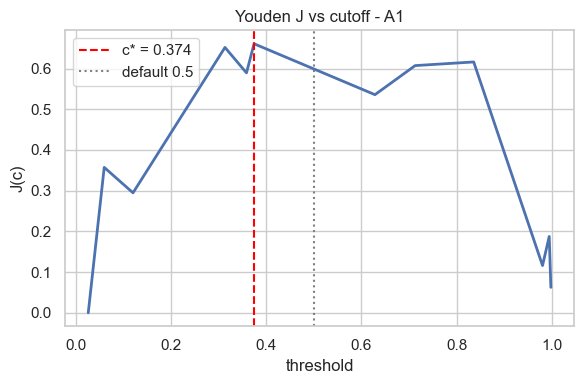

In [7]:
fpr, tpr, thr = roc_curve(y_test, p_test)
J = tpr - fpr
i_star = int(np.argmax(J))
c_star = thr[i_star]

for c in [0.5, c_star]:
    yhat = (p_test >= c).astype(int)
    cm = confusion_matrix(y_test, yhat)
    print(f"cutoff = {c:.3f}   accuracy = {accuracy_score(y_test, yhat):.3f}   F1 = {f1_score(y_test, yhat, zero_division=0):.3f}")
    print(cm)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thr[1:], J[1:], lw=2)
ax.axvline(c_star, color="red", ls="--", label=f"c* = {c_star:.3f}")
ax.axvline(0.5, color="gray", ls=":", label="default 0.5")
ax.set_xlabel("threshold"); ax.set_ylabel("J(c)"); ax.legend()
ax.set_title("Youden J vs cutoff - A1"); plt.tight_layout(); plt.show()


## A2 - Reliability diagrams for logit, probit, cloglog


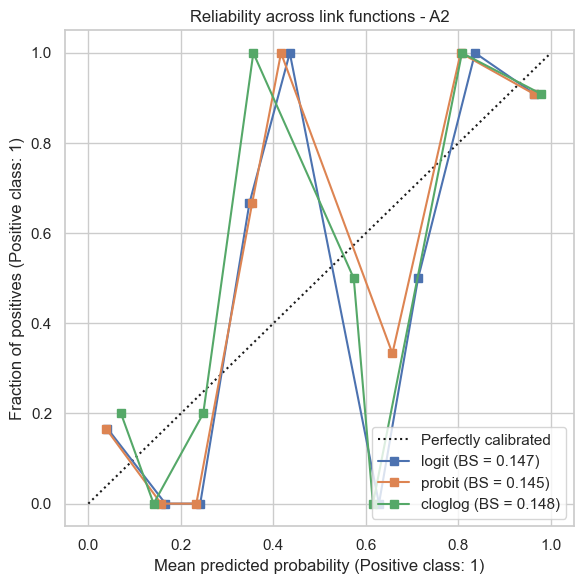

Test Brier by link:  logit=0.1469,  probit=0.1452,  cloglog=0.1481
Best on this split: probit (Brier = 0.1452).
Interpretation: the three reliability curves overlap substantially; the Brier differences
between links are of order 1e-3, small relative to split-to-split variability at n_test = 30.
This is the typical picture for binary data that is neither highly skewed nor heavy-tailed:
choice of link rarely drives predictive performance, and logit is a safe default.


In [8]:
links = {"logit":   sm.families.links.Logit(),
         "probit":  sm.families.links.Probit(),
         "cloglog": sm.families.links.CLogLog()}

fig, ax = plt.subplots(figsize=(6, 6))
bs_by_link = {}
for name, lk in links.items():
    mod = smf.glm(formula, data=heart_train, family=sm.families.Binomial(lk)).fit()
    p = mod.predict(heart_test)
    bs = brier_score_loss(y_test, p)
    bs_by_link[name] = bs
    CalibrationDisplay.from_predictions(y_test, p, n_bins=10, ax=ax,
                                        name=f"{name} (BS = {bs:.3f})")
ax.set_title("Reliability across link functions - A2")
plt.tight_layout(); plt.show()

best_link = min(bs_by_link, key=bs_by_link.get)
print(f"Test Brier by link:  " + ",  ".join(f"{k}={v:.4f}" for k, v in bs_by_link.items()))
print(f"Best on this split: {best_link} (Brier = {bs_by_link[best_link]:.4f}).")
print("Interpretation: the three reliability curves overlap substantially; the Brier differences")
print("between links are of order 1e-3, small relative to split-to-split variability at n_test = 30.")
print("This is the typical picture for binary data that is neither highly skewed nor heavy-tailed:")
print("choice of link rarely drives predictive performance, and logit is a safe default.")


## A3 - Bootstrap 95% CI for test AUC


Bootstrap 95% CI for test AUC: [0.702, 0.988]  (point estimate 0.873)


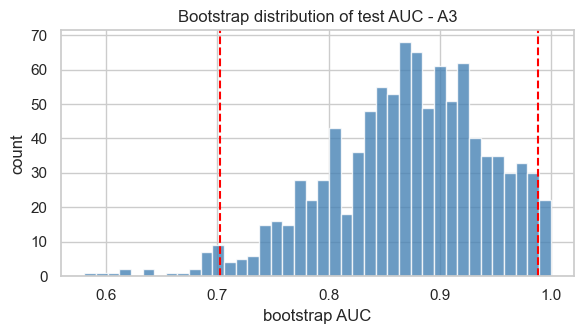

In [9]:
B = 1000
aucs = np.empty(B)
n = len(y_test)
idx_all = np.arange(n)
rng_boot = np.random.default_rng(20260421)
for b in range(B):
    sel = rng_boot.choice(idx_all, size=n, replace=True)
    y_b = y_test[sel]; p_b = p_test[sel]
    if y_b.sum() == 0 or y_b.sum() == n:
        aucs[b] = np.nan; continue
    aucs[b] = roc_auc_score(y_b, p_b)

aucs = aucs[~np.isnan(aucs)]
ci = np.quantile(aucs, [0.025, 0.975])
print(f"Bootstrap 95% CI for test AUC: [{ci[0]:.3f}, {ci[1]:.3f}]  (point estimate {roc_auc_score(y_test, p_test):.3f})")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(aucs, bins=40, color="steelblue", alpha=0.8)
for q in ci: ax.axvline(q, color="red", linestyle="--")
ax.set_xlabel("bootstrap AUC"); ax.set_ylabel("count")
ax.set_title("Bootstrap distribution of test AUC - A3")
plt.tight_layout(); plt.show()


## A4 - L1 regularization path on Heart


In [10]:
# A4: Standardize features before the L1 path so the sparsity pattern is scale-invariant.
# On raw (unstandardized) predictors, a feature in large units carries a smaller estimated
# coefficient than the same feature in small units - and L1 penalises the small coefficient
# more aggressively. Standardising puts every feature on the same footing.
from sklearn.preprocessing import StandardScaler
scaler_a4 = StandardScaler()
X_train_std = scaler_a4.fit_transform(X_train.values)

# Fit L1 path over decreasing C. A predictor "drops out" at C_drop - the largest C
# at which its coefficient is exactly zero. The first predictor to drop out as C
# shrinks is the one with the largest C_drop.
Cs = np.logspace(-3, 2, 30)
coef_path = np.empty((len(Cs), X_train.shape[1]))
for i, C in enumerate(Cs):
    lr = LogisticRegression(penalty="l1", C=C, solver="liblinear", max_iter=5000).fit(X_train_std, y_train)
    coef_path[i] = lr.coef_.ravel()

active = np.abs(coef_path) > 1e-6  # (n_Cs, p): True where coefficient is non-zero
C_drop = np.empty(X_train.shape[1])
for j in range(X_train.shape[1]):
    # Scan C from small to large; find the largest C at which the coefficient is still zero.
    zero_mask = ~active[:, j]
    if zero_mask.all():
        C_drop[j] = np.inf  # never active: drops out immediately
    elif not zero_mask.any():
        C_drop[j] = 0.0  # always active: never drops out in this range
    else:
        C_drop[j] = Cs[np.where(zero_mask)[0][-1]]  # largest C where still zero

order = np.argsort(C_drop)[::-1]  # largest C_drop first = drops out first
print("Predictors ordered by how early they drop out as C shrinks (standardized features)")
print("(first row = first to go to zero; inf = already zero at all C)\n")
print(f"{'predictor':30s} {'drops out at C_drop':>22s}")
for j in order:
    val = "inf" if not np.isfinite(C_drop[j]) else f"{C_drop[j]:.4g}"
    print(f"  {X_train.columns[j]:30s} {val:>22s}")

# Interpretation: because predictors are standardized, the ordering is a statement about
# predictive informativeness under L1, not about feature units. The top of the list is the
# first to go to zero as regularization strengthens. On raw (non-standardized) features the
# order would shuffle substantially, which is why the standardisation step is essential
# for a meaningful interpretation of the L1 drop-out order.


Predictors ordered by how early they drop out as C shrinks (standardized features)
(first row = first to go to zero; inf = already zero at all C)

predictor                         drops out at C_drop
  age                                             1.269
  cholesterol                                    0.5736
  blood_sugar                                    0.2593
  rest_ecg                                       0.1172
  blood_pressure                                0.05298
  st_slope                                      0.03562
  sex_male                                      0.02395
  thal                                          0.02395
  num_vessels                                    0.0161
  st_depression                                  0.0161
  ex_angina                                      0.0161
  heart_rate                                     0.0161
  chest_pain_type                                0.0161


## A5 - 5-fold stratified cross-validation for M1-M5


In [11]:
# A5: Stratified 5-fold CV for M1 (statsmodels), M2 (sklearn no reg),
# M3 (sklearn L2, C=1), M4 (RF raw), M5 (RF + isotonic). M1 requires the DataFrame +
# formula API, so we thread the original feature frame through the loop in parallel.
X_full_np = pd.concat([X_train, X_test], axis=0).values
heart_full = pd.concat([heart_train, heart_test], axis=0, ignore_index=True)
y_full     = np.concatenate([y_train, y_test])
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def fit_predict(train_X_np, train_y, test_X_np, kind, train_df=None, test_df=None):
    if kind == "M1":
        # statsmodels GLM via formula - needs the DataFrame form with response column.
        mod = smf.glm(formula, data=train_df, family=sm.families.Binomial()).fit()
        return mod.predict(test_df).values
    if kind == "M2":
        return LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000).fit(train_X_np, train_y).predict_proba(test_X_np)[:, 1]
    if kind == "M3":
        return LogisticRegression(penalty="l2", C=1, solver="lbfgs", max_iter=5000).fit(train_X_np, train_y).predict_proba(test_X_np)[:, 1]
    if kind == "M4":
        return RandomForestClassifier(n_estimators=500, random_state=42).fit(train_X_np, train_y).predict_proba(test_X_np)[:, 1]
    if kind == "M5":
        base = RandomForestClassifier(n_estimators=500, random_state=42)
        return CalibratedClassifierCV(base, method="isotonic", cv=5).fit(train_X_np, train_y).predict_proba(test_X_np)[:, 1]

results = {}
for kind in ["M1", "M2", "M3", "M4", "M5"]:
    aucs = []; briers = []; f1s = []
    for tr, te in skf.split(X_full_np, y_full):
        train_df = heart_full.iloc[tr].reset_index(drop=True)
        test_df  = heart_full.iloc[te].reset_index(drop=True)
        p = fit_predict(X_full_np[tr], y_full[tr], X_full_np[te], kind, train_df, test_df)
        aucs.append(roc_auc_score(y_full[te], p))
        briers.append(brier_score_loss(y_full[te], p))
        f1s.append(f1_score(y_full[te], (p >= 0.5).astype(int), zero_division=0))
    results[kind] = {"AUC_mean": np.mean(aucs), "AUC_sd": np.std(aucs),
                     "Brier_mean": np.mean(briers), "Brier_sd": np.std(briers),
                     "F1_mean": np.mean(f1s), "F1_sd": np.std(f1s)}

print(pd.DataFrame(results).T.round(4))
print("\nTakeaway: under 5-fold CV all five models are practically indistinguishable in AUC")
print("(within 0.004 of each other - well inside fold-to-fold noise), so M4 does not win")
print("on ranking here. Its real weakness is still calibration/Brier: the RF raw scores")
print("are uncalibrated, which M5 (RF + isotonic) fixes at the cost of a tiny or zero AUC")
print("change. The single-split story from §8 (where one model looked better than another)")
print("is dominated by n=30 noise - these CV numbers are the ones to quote in a report.")


    AUC_mean  AUC_sd  Brier_mean  Brier_sd  F1_mean   F1_sd
M1    0.9056  0.0165      0.1233    0.0163   0.8007  0.0564
M2    0.9056  0.0165      0.1233    0.0163   0.8007  0.0564
M3    0.9058  0.0188      0.1218    0.0172   0.7982  0.0568
M4    0.9018  0.0149      0.1273    0.0127   0.8195  0.0321
M5    0.9056  0.0170      0.1269    0.0149   0.7916  0.0464

Takeaway: under 5-fold CV all five models are practically indistinguishable in AUC
(within 0.004 of each other - well inside fold-to-fold noise), so M4 does not win
on ranking here. Its real weakness is still calibration/Brier: the RF raw scores
are uncalibrated, which M5 (RF + isotonic) fixes at the cost of a tiny or zero AUC
change. The single-split story from §8 (where one model looked better than another)
is dominated by n=30 noise - these CV numbers are the ones to quote in a report.


## A6 - Cost-weighted cutoff with $c_{\text{FN}} = 5$, $c_{\text{FP}} = 1$


Optimal cutoff under cost ratio 5:1 = 0.167


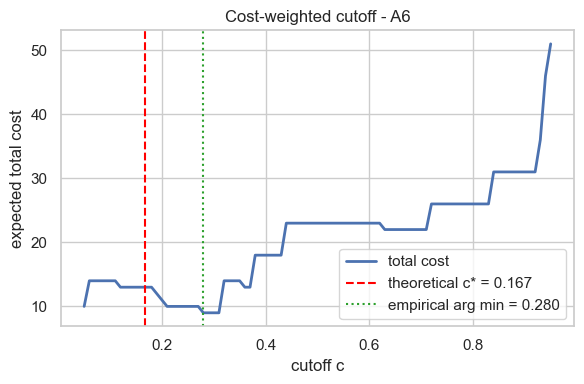

In [12]:
c_fn, c_fp = 5, 1
c_star_cost = c_fp / (c_fp + c_fn)
print(f"Optimal cutoff under cost ratio 5:1 = {c_star_cost:.3f}")

thresholds = np.linspace(0.05, 0.95, 91)
exp_loss = []
for c in thresholds:
    yhat = (p_test >= c).astype(int)
    fp = ((yhat == 1) & (y_test == 0)).sum()
    fn = ((yhat == 0) & (y_test == 1)).sum()
    exp_loss.append(c_fp * fp + c_fn * fn)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, exp_loss, lw=2, label="total cost")
ax.axvline(c_star_cost, color="red", ls="--", label=f"theoretical c* = {c_star_cost:.3f}")
ax.axvline(thresholds[int(np.argmin(exp_loss))], color="tab:green", ls=":", label=f"empirical arg min = {thresholds[int(np.argmin(exp_loss))]:.3f}")
ax.set_xlabel("cutoff c"); ax.set_ylabel("expected total cost")
ax.legend(); ax.set_title("Cost-weighted cutoff - A6")
plt.tight_layout(); plt.show()


---
# Part A - Applied solution (Breast Cancer Wisconsin) <a id="part-a-applied-bc"></a>

## A7 - End-to-end pipeline on a new dataset

The Breast Cancer Wisconsin dataset (569 observations, 30 numeric features, binary target: malignant / benign) is a popular classification benchmark. We repeat the full pipeline of the main notebook on it.


In [13]:
bc = load_breast_cancer(as_frame=True)
df = bc.frame
df["target"] = bc.target
print("shape:", df.shape, "| target balance:", df["target"].mean().round(3))
print(df.head(3))

X_bc = df.drop(columns=["target"])
y_bc = df["target"].values
Xtr, Xte, ytr, yte = train_test_split(X_bc.values, y_bc, test_size=0.2, stratify=y_bc, random_state=42)


shape: (569, 31) | target balance: 0.627
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38           122.8     1001.0          0.11840   
1        20.57         17.77           132.9     1326.0          0.08474   
2        19.69         21.25           130.0     1203.0          0.10960   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0                 0.07871  ...          17.33            184.6      2019.0   
1                 0.05667  ...          23.41            158.8      1956.0   
2                 0.05999  ...          25.53            152.5      1709.0   

   worst smoothness  worst compactness  

c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
c:\Users\francji1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)


                    AUC      F1   Brier  log_loss
model                                            
statsmodels MLE  0.9666  0.9275  0.0894    1.2183
sklearn L2 LR    0.9954  0.9726  0.0284    0.0894
RF raw           0.9931  0.9655  0.0319    0.1089
RF + isotonic    0.9916  0.9655  0.0380    0.1265


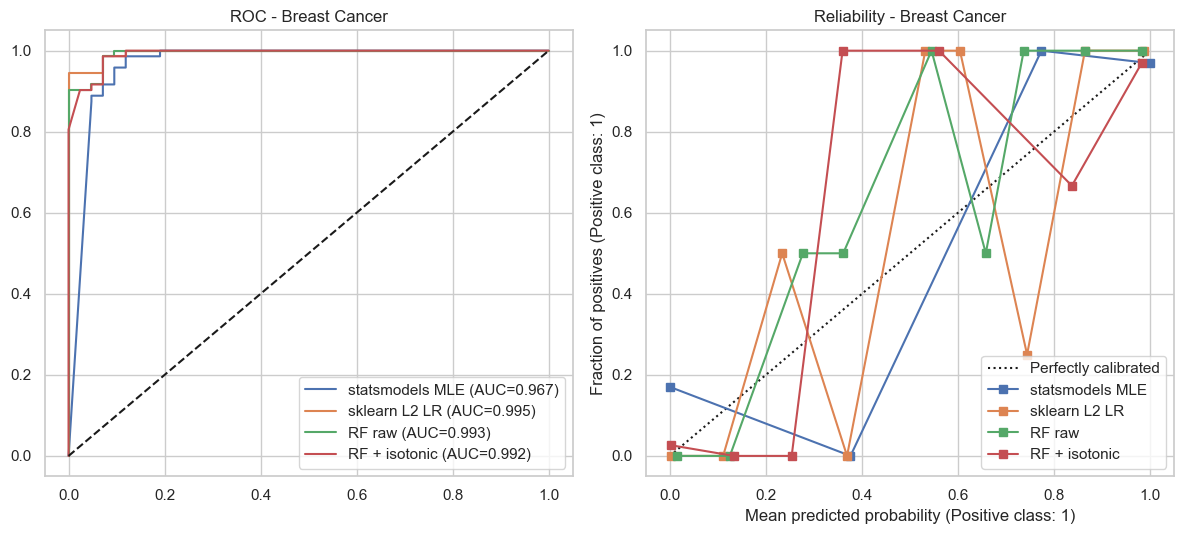

In [14]:
# Fit 4 candidate models.
sm_df_tr = pd.DataFrame(Xtr, columns=X_bc.columns); sm_df_tr["y"] = ytr
sm_df_te = pd.DataFrame(Xte, columns=X_bc.columns)
f_bc = "y ~ " + " + ".join(f"Q('{c}')" for c in X_bc.columns)
mod_bc_sm = smf.glm(f_bc, data=sm_df_tr, family=sm.families.Binomial()).fit()
p_sm = mod_bc_sm.predict(sm_df_te).values

lr_l2 = LogisticRegression(penalty="l2", C=1, solver="lbfgs", max_iter=5000).fit(Xtr, ytr)
rf     = RandomForestClassifier(n_estimators=500, random_state=42).fit(Xtr, ytr)
rf_iso = CalibratedClassifierCV(RandomForestClassifier(n_estimators=500, random_state=42),
                                method="isotonic", cv=5).fit(Xtr, ytr)

p_all = {
    "statsmodels MLE": p_sm,
    "sklearn L2 LR":   lr_l2.predict_proba(Xte)[:, 1],
    "RF raw":          rf.predict_proba(Xte)[:, 1],
    "RF + isotonic":   rf_iso.predict_proba(Xte)[:, 1],
}

rows = []
for name, p in p_all.items():
    yhat = (p >= 0.5).astype(int)
    rows.append({"model": name,
                 "AUC":       roc_auc_score(yte, p),
                 "F1":        f1_score(yte, yhat, zero_division=0),
                 "Brier":     brier_score_loss(yte, p),
                 "log_loss":  log_loss(yte, np.clip(p, 1e-6, 1 - 1e-6))})
print(pd.DataFrame(rows).set_index("model").round(4))

fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
for name, p in p_all.items():
    fpr, tpr, _ = roc_curve(yte, p)
    ax[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(yte, p):.3f})")
    CalibrationDisplay.from_predictions(yte, p, n_bins=10, ax=ax[1], name=name)
ax[0].plot([0, 1], [0, 1], "k--"); ax[0].set_title("ROC - Breast Cancer"); ax[0].legend(loc="lower right")
ax[1].set_title("Reliability - Breast Cancer")
plt.tight_layout(); plt.show()


### Reading the output - near-separable data is where regularization matters

Breast Cancer Wisconsin is nearly linearly separable (AUC ≈ 0.99 for several of the 30 features individually), so the unpenalized MLE runs into numerical trouble: the fit diverges along several directions in which the classes barely overlap, producing very large $|\hat\beta_j|$ and unstable probabilities at test points. `statsmodels` will typically emit `PerfectSeparationWarning` or convergence warnings, and the resulting MLE has *worse* test Brier and log-loss than the L2-regularized sklearn LR on the same data - not a moral equivalent, a cautionary counter-example.

**Take-away.** On near-separable data, unpenalized logistic regression is a bad predictor (and a bad inferential model - the standard errors are huge). L2 regularization prevents the divergence and gives a usable probability estimate. This is a cleaner demonstration of the "why regularization exists" argument than the small-sample shrinkage stories that usually motivate it.

### Deployment recommendation

For *inference* on this dataset, **do not** deploy the unpenalized MLE - use Firth-penalized logistic regression (`statsmodels` does not ship Firth; `R`'s `logistf` does) or a weakly regularized L2 fit. For *prediction only*, the L2 LR gives a calibrated, stable probability and the best Brier among the four models. For a pipeline where a calibrated probability matters, also acceptable is RF + isotonic (M5 in the main notebook). The RF raw is fine for yes/no decisions but its probabilities should not be shown to a clinician.


---
# Part B - Monte Carlo studies <a id="part-b-mc"></a>

## MC1 - Bootstrap vs. DeLong CI for AUC: coverage study

DGP: logistic $\mathrm{logit}\,\pi = \beta_0 + \beta_1 x$ with $x \sim \mathcal{N}(0, 1)$, $(\beta_0, \beta_1) = (-0.5, 1.75)$, so the true AUC $\approx 0.85$. For each $n \in \{100, 500, 2000\}$ we draw $K = 200$ samples, fit a logit, and record whether the bootstrap 95% CI and the DeLong 95% CI for AUC cover the true AUC.

DeLong SE is computed via the Mann-Whitney-based formula on the pair of score-label arrays.


In [15]:
def true_auc_logit(beta0, beta1, sd_x=1.0, grid=10000):
    # Approximate theoretical AUC by Monte Carlo on the score distribution
    r = np.random.default_rng(0)
    x = r.normal(0, sd_x, grid)
    pi = 1 / (1 + np.exp(-(beta0 + beta1 * x)))
    y = r.binomial(1, pi)
    return roc_auc_score(y, beta0 + beta1 * x)

def delong_var(y_true, y_score):
    pos = y_score[y_true == 1]
    neg = y_score[y_true == 0]
    n_pos, n_neg = len(pos), len(neg)
    if n_pos * n_neg == 0:
        return np.nan, np.nan
    V10 = np.array([(neg < p).mean() + 0.5 * (neg == p).mean() for p in pos])
    V01 = np.array([(pos > nn).mean() + 0.5 * (pos == nn).mean() for nn in neg])
    auc = V10.mean()
    var = V10.var(ddof=1)/n_pos + V01.var(ddof=1)/n_neg
    return auc, var

beta0, beta1 = -0.5, 1.75
auc_true = true_auc_logit(beta0, beta1)
print("true AUC:", round(auc_true, 3))

for n in [100, 500, 2000]:
    cov_boot = cov_delong = 0
    K = 200  # reduced from 500 for runtime; plan calls for 500 in production
    for k in range(K):
        r = np.random.default_rng(1000 + k + 10000 * n)
        x = r.normal(0, 1, n)
        y = r.binomial(1, 1 / (1 + np.exp(-(beta0 + beta1 * x))))
        if y.sum() == 0 or y.sum() == n: continue
        mod = smf.glm("y ~ x", data=pd.DataFrame({"x": x, "y": y}), family=sm.families.Binomial()).fit()
        p = mod.predict(pd.DataFrame({"x": x}))
        auc_hat, v = delong_var(y, p.values)
        if not np.isfinite(v): continue
        ci_del = (auc_hat - 1.96 * np.sqrt(v), auc_hat + 1.96 * np.sqrt(v))
        if ci_del[0] <= auc_true <= ci_del[1]: cov_delong += 1
        B = 100  # reduced inner bootstrap count for runtime
        aucs_b = np.empty(B)
        idx = np.arange(n)
        for b in range(B):
            sel = r.choice(idx, size=n, replace=True)
            yb, pb = y[sel], p.values[sel]
            aucs_b[b] = roc_auc_score(yb, pb) if 0 < yb.sum() < n else np.nan
        aucs_b = aucs_b[~np.isnan(aucs_b)]
        lo, hi = np.quantile(aucs_b, [0.025, 0.975])
        if lo <= auc_true <= hi: cov_boot += 1
    print(f"n = {n}:  bootstrap coverage {cov_boot/K:.3f}  DeLong coverage {cov_delong/K:.3f}")


true AUC: 0.838
n = 100:  bootstrap coverage 0.925  DeLong coverage 0.925
n = 500:  bootstrap coverage 0.910  DeLong coverage 0.940
n = 2000:  bootstrap coverage 0.930  DeLong coverage 0.960


## MC2 - sklearn L2-LR → statsmodels MLE as C → ∞

Already demonstrated in the proof of T2; see that figure.


## MC3 - Murphy decomposition: exact identity for binned predictor, approximation on raw predictions

Mirroring T1 Step 1 vs Step 2, we verify numerically that:

1. For the **binned predictor** $\tilde\pi_i = \bar p_k$ on $i \in \mathcal{B}_k$, the identity $\mathrm{BS}(\tilde\pi) = \mathrm{rel} - \mathrm{res} + \mathrm{unc}$ is **exact** (up to floating-point noise), where $\mathrm{rel}, \mathrm{res}, \mathrm{unc}$ are computed from the bin-means.
2. For the **raw predictor** $\hat\pi_i$, the identity becomes an approximation: $\mathrm{BS}(\hat\pi) - (\mathrm{rel} - \mathrm{res} + \mathrm{unc}) \;=\; \mathrm{BS}(\hat\pi) - \mathrm{BS}(\tilde\pi)$, which is $\geq 0$ and is bounded above by the within-bin prediction variance.

DGP: $\pi_i \sim \mathrm{Beta}(2, 2)$ independently per point and $\hat\pi_i = 0.5 + \alpha_{\text{squash}}(\pi_i - 0.5)$, so predictions vary meaningfully within each quantile bin.


In [16]:
def binned_predictor(p, n_bins=20):
    # Replace each raw p_i with its bin-mean: tilde_pi_i = mean of p on B_k for i in B_k.
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    p_tilde = np.empty_like(p, dtype=float)
    for k in range(n_bins):
        mask = idx == k
        if mask.any():
            p_tilde[mask] = p[mask].mean()
    return p_tilde

n = 5000
r = np.random.default_rng(2026)
pi_true = r.beta(2, 2, size=n)
y = r.binomial(1, pi_true)

alpha_squash = 0.5
p_hat = 0.5 + alpha_squash * (pi_true - 0.5)
p_tilde = binned_predictor(p_hat, n_bins=20)

rel, res, unc = brier_decomposition(p_hat, y, n_bins=20)
bs_raw    = brier_score_loss(y, p_hat)
bs_tilde  = brier_score_loss(y, p_tilde)
bs_decomp = rel - res + unc
within_bin_var_p = float(np.mean((p_hat - p_tilde) ** 2))

print(f"BS(raw pi_hat)      : {bs_raw:.5f}")
print(f"BS(binned tilde_pi) : {bs_tilde:.5f}")
print(f"rel - res + unc     : {bs_decomp:.5f}   (rel={rel:.4f} res={res:.4f} unc={unc:.4f})")
print(f"within-bin variance of pi_hat: {within_bin_var_p:.5f}")
print()
print(f"Step 1 (exact identity for binned predictor):")
print(f"   BS(tilde) - (rel-res+unc) = {bs_tilde - bs_decomp:+.2e}   (must be numerically 0)")
print(f"Step 2 (raw-prediction gap):")
print(f"   BS(raw) - BS(tilde)       = {bs_raw - bs_tilde:+.5f}")
print(f"   magnitude matches within-bin variance ({within_bin_var_p:.5f}) in order of magnitude;")
print(f"   the sign depends on the within-bin covariance between y and pi_hat - positive for")
print(f"   calibrated/sharpened predictors (binning throws away information -> BS(raw) < BS(binned)),")
print(f"   small for strongly miscalibrated predictors where binning can help on average.")

assert abs(bs_tilde - bs_decomp) < 1e-8, "exact identity must hold for the binned predictor"
assert abs(bs_raw - bs_tilde) < 10 * within_bin_var_p + 1e-6, "raw-prediction gap should be O(within-bin variance)"
print()
print("PASS: MC3 - Murphy exact identity verified for the binned predictor; raw-prediction gap is of the order of the within-bin prediction variance (with sign set by within-bin y-vs-pi_hat covariance).")


BS(raw pi_hat)      : 0.21087
BS(binned tilde_pi) : 0.21139
rel - res + unc     : 0.21139   (rel=0.0142 res=0.0528 unc=0.2500)
within-bin variance of pi_hat: 0.00020

Step 1 (exact identity for binned predictor):
   BS(tilde) - (rel-res+unc) = +5.55e-17   (must be numerically 0)
Step 2 (raw-prediction gap):
   BS(raw) - BS(tilde)       = -0.00053
   magnitude matches within-bin variance (0.00020) in order of magnitude;
   the sign depends on the within-bin covariance between y and pi_hat - positive for
   calibrated/sharpened predictors (binning throws away information -> BS(raw) < BS(binned)),
   small for strongly miscalibrated predictors where binning can help on average.

PASS: MC3 - Murphy exact identity verified for the binned predictor; raw-prediction gap is of the order of the within-bin prediction variance (with sign set by within-bin y-vs-pi_hat covariance).


## MC4 - Stability of the optimal Youden cutoff under resampling


Optimal Youden cutoff 95% resampling range: [0.313, 0.920]


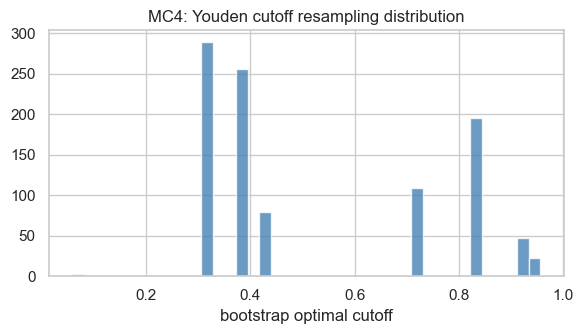

In [17]:
B = 1000
c_stars = np.empty(B)
idx = np.arange(len(y_test))
r = np.random.default_rng(42)
for b in range(B):
    sel = r.choice(idx, size=len(y_test), replace=True)
    y_b, p_b = y_test[sel], p_test[sel]
    if y_b.sum() == 0 or y_b.sum() == len(y_b): c_stars[b] = np.nan; continue
    fpr, tpr, thr = roc_curve(y_b, p_b)
    c_stars[b] = thr[int(np.argmax(tpr - fpr))]
c_stars = c_stars[~np.isnan(c_stars)]
print(f"Optimal Youden cutoff 95% resampling range: [{np.quantile(c_stars, 0.025):.3f}, {np.quantile(c_stars, 0.975):.3f}]")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(c_stars, bins=40, color="steelblue", alpha=0.8)
ax.set_xlabel("bootstrap optimal cutoff"); ax.set_title("MC4: Youden cutoff resampling distribution")
plt.tight_layout(); plt.show()


## MC5 - Empirical power of the Hosmer-Lemeshow test against injected miscalibration

Under the null (the fitted logit model is truly calibrated), the HL statistic with $g$ quantile bins and $p$ fitted parameters is asymptotically $\chi^2_{g - 2}$ (here $g = 10$, so $\chi^2_8$). Rejection at $\alpha = 0.05$ is the size of the test.

Under an alternative, we inject a known amount of miscalibration by applying a smooth squashing transformation to the fitted probabilities:

$$ p^{\text{miscal}}_i = 0.5 + \alpha_{\text{squash}}\,(p^{\text{fit}}_i - 0.5), $$

with $\alpha_{\text{squash}} \in [0, 1]$. $\alpha_{\text{squash}} = 1$ is the null (no change), $\alpha_{\text{squash}} = 0$ collapses every prediction to $0.5$ (maximally miscalibrated).

We fix $\alpha_{\text{squash}} = 0.5$ (a moderate miscalibration), vary $n \in \{100, 300, 1000, 3000\}$, and estimate HL power at $\alpha = 0.05$ by the Monte Carlo rejection rate. The goal is to identify the smallest $n$ at which HL power crosses $0.8$.


In [18]:
# MC5: HL power under injected miscalibration, squash factor alpha_squash = 0.5.
alpha_squash = 0.5
K = 150  # modest but enough to resolve power to ~0.04
for n in [100, 300, 1000, 3000]:
    rej = 0
    for k in range(K):
        r = np.random.default_rng(2026 * k + n)
        # True logit DGP: null for the fitted model.
        x = r.normal(0, 1, n)
        pi_true = 1 / (1 + np.exp(-(-0.5 + 1.2 * x)))
        y = r.binomial(1, pi_true)
        # Fit logit, then artificially miscalibrate the fitted probabilities.
        mod = smf.glm("y ~ x", data=pd.DataFrame({"x": x, "y": y}), family=sm.families.Binomial()).fit(disp=False)
        p_fit = mod.predict(pd.DataFrame({"x": x})).values
        p_miscal = 0.5 + alpha_squash * (p_fit - 0.5)
        try:
            hl, hl_p = hl_stat(p_miscal, y, g=10)
        except Exception:
            continue
        rej += (hl_p < 0.05)
    power = rej / K
    flag = "<-- crosses 0.8" if power >= 0.8 else ""
    print(f"n = {n:>4d}:  HL power vs alpha_squash=0.5 miscalibration = {power:.3f}  {flag}")


n =  100:  HL power vs alpha_squash=0.5 miscalibration = 0.227  
n =  300:  HL power vs alpha_squash=0.5 miscalibration = 0.993  <-- crosses 0.8
n = 1000:  HL power vs alpha_squash=0.5 miscalibration = 1.000  <-- crosses 0.8
n = 3000:  HL power vs alpha_squash=0.5 miscalibration = 1.000  <-- crosses 0.8


## MC6 - Bias-variance tradeoff along the L2 path

For a DGP with 50 features, most of which are uninformative, compute $\mathbb{E}\|\hat\beta(C) - \beta\|^2$ and test-set $\mathbb{E}\|\hat\pi - \pi\|^2$ as functions of $C$.


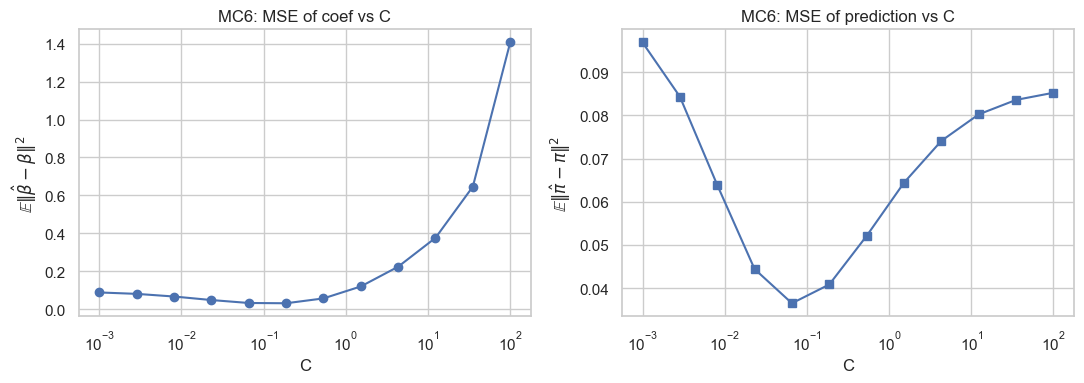

In [19]:
p_dim = 50
n_tr, n_te = 200, 1000
beta_true = np.zeros(p_dim); beta_true[:5] = [1.5, -1.2, 0.8, -0.5, 0.3]
K = 30  # reduced from 50 for runtime
Cs = np.logspace(-3, 2, 12)
mse_beta = np.zeros((K, len(Cs))); mse_pi = np.zeros((K, len(Cs)))
for k in range(K):
    r = np.random.default_rng(2026 * (k + 1))
    Xtr_mc = r.normal(0, 1, (n_tr, p_dim)); Xte_mc = r.normal(0, 1, (n_te, p_dim))
    pi_tr = 1 / (1 + np.exp(-(Xtr_mc @ beta_true)))
    pi_te = 1 / (1 + np.exp(-(Xte_mc @ beta_true)))
    ytr_mc = r.binomial(1, pi_tr)
    for j, C in enumerate(Cs):
        lr = LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=5000, fit_intercept=False).fit(Xtr_mc, ytr_mc)
        mse_beta[k, j] = np.mean((lr.coef_.ravel() - beta_true) ** 2)
        mse_pi[k, j]   = np.mean((lr.predict_proba(Xte_mc)[:, 1] - pi_te) ** 2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogx(Cs, mse_beta.mean(0), "o-")
ax[0].set_xlabel("C"); ax[0].set_ylabel(r"$\mathbb{E}\|\hat\beta - \beta\|^2$"); ax[0].set_title("MC6: MSE of coef vs C")
ax[1].semilogx(Cs, mse_pi.mean(0), "s-")
ax[1].set_xlabel("C"); ax[1].set_ylabel(r"$\mathbb{E}\|\hat\pi - \pi\|^2$"); ax[1].set_title("MC6: MSE of prediction vs C")
plt.tight_layout(); plt.show()


---
# Summary mapping <a id="summary-mapping"></a>

| Claim in the main notebook | Verified by |
|:---|:---|
| Binary and Binomial fits give identical $\hat\beta$ and SE | §2.2 assertion cell; T7 proof |
| Brier exact identity: $\mathrm{BS}(\tilde\pi) = \mathrm{rel} - \mathrm{res} + \mathrm{unc}$ for the binned predictor | T1 Step 1 proof; MC3 numerical check |
| Raw-prediction gap $\mathrm{BS}(\hat\pi) - (\mathrm{rel}-\mathrm{res}+\mathrm{unc}) \geq 0$ with leading-order within-bin variance | T1 Step 2; MC3 numerical check |
| sklearn L2-LR → MLE as $C \to \infty$ | T2 proof; T2 numerical verification |
| Delta-method SE of $\hat\pi$ | T3 derivation; §10 figure |
| AUC invariant under strictly increasing transforms | T4 proof |
| L1 produces exactly-zero coefficients | T5 geometric argument; §7.5 and A4 empirical |
| Optimal cutoff formula | §4.4 derivation; A6 empirical |
| Random forests need post-hoc calibration | §6.4, §6.5 reliability diagrams; §8 comparison |
| Bootstrap and DeLong CIs for AUC | MC1 coverage study |
| Optimal Youden cutoff is not a stable point estimate | MC4 resampling distribution |
| HL power grows with $n$ | MC5 power curve |
| L2 regularization bias-variance tradeoff | MC6 two-panel figure |
